# Fitting a Logistic Regression

Using the example from section 11.10 from Montgomery and Runger Textbook

In [19]:
# By default in a Jupyter notebook, a cell with multiple print commands, when run, would print only the last one. 
# This piece of code would modify that to print all the relevant lines in the cell.  
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [20]:
import pandas as pd
import statsmodels.formula.api as sm

In [21]:
oring = pd.read_csv("challenger_ORing_data.csv")
oring.head()
oring = oring.rename(columns={"Temperature": "temperature", "O-Ring Failure": "failure"})
oring.head()

,Temperature,O-Ring Failure
0,53,1
1,56,1
2,57,1
3,63,0
4,66,0


,temperature,failure
0,53,1
1,56,1
2,57,1
3,63,0
4,66,0


<Axes: xlabel='temperature', ylabel='failure'>

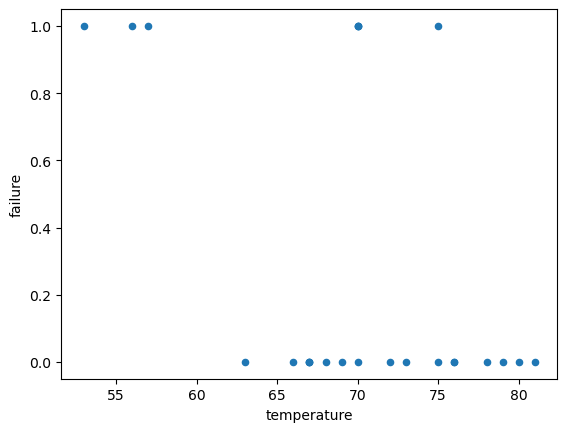

In [22]:
oring.plot('temperature', 'failure', 'scatter')

In [23]:
logistic_reg = sm.logit('failure ~ temperature', data=oring).fit()
print(logistic_reg.summary())

Optimization terminated successfully.
         Current function value: 0.479801
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                failure   No. Observations:                   24
Model:                          Logit   Df Residuals:                       22
Method:                           MLE   Df Model:                            1
Date:                Thu, 24 Apr 2025   Pseudo R-squ.:                  0.2052
Time:                        11:37:39   Log-Likelihood:                -11.515
converged:                       True   LL-Null:                       -14.487
Covariance Type:            nonrobust   LLR p-value:                   0.01477
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      10.8753      5.703      1.907      0.057      -0.303      22.053
temperature    -0.1713    

In [24]:
print(logistic_reg.params)

Intercept      10.875349
temperature    -0.171321
dtype: float64


In [25]:
print(dir(logistic_reg))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_cache', '_data_attr', '_data_in_cache', '_get_endog_name', '_get_robustcov_results', '_get_wald_nonlinear', '_transform_predict_exog', '_use_t', 'aic', 'bic', 'bse', 'conf_int', 'converged', 'cov_kwds', 'cov_params', 'cov_type', 'df_model', 'df_resid', 'f_test', 'fittedvalues', 'get_distribution', 'get_influence', 'get_margeff', 'get_prediction', 'im_ratio', 'info_criteria', 'initialize', 'k_constant', 'llf', 'llnull', 'llr', 'llr_pvalue', 'load', 'method', 'mle_retvals', 'mle_settings', 'model', 'nobs', 'normalized_cov_params', 'params', 'pred_table', 'predict', 'prsquared', 'pvalues', 'remove_data', 'resid_dev', 'resid_generali

In [26]:
print(logistic_reg.conf_int(0.05))
print(logistic_reg.conf_int(0.01))

                    0          1
Intercept   -0.302589  22.053287
temperature -0.334864  -0.007777
                    0          1
Intercept   -3.814951  25.565650
temperature -0.386253   0.043612


In [27]:
import numpy as np
odds_ratios = pd.DataFrame(
    {
        "OR": logistic_reg.params
    }
)
odds_ratios = np.exp(odds_ratios)
print(odds_ratios)

                       OR
Intercept    52857.197371
temperature      0.842551


### Using Sklearn to fit a logistic regression

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

logreg = LogisticRegression()

In [30]:
X_train, X_test, y_train, y_test = train_test_split(oring[['temperature']], oring['failure'], test_size=0.3, random_state=0)
#X_ = oring[['temperature']]
#y_ = oring['failure']
logreg.fit(X_train, y_train)

LogisticRegression()

In [31]:
y_pred = logreg.predict(X_test)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.75


In [32]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[5 0]
 [2 1]]


In [33]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      1.00      0.83         5
           1       1.00      0.33      0.50         3

    accuracy                           0.75         8
   macro avg       0.86      0.67      0.67         8
weighted avg       0.82      0.75      0.71         8



<Figure size 640x480 with 0 Axes>

(0.0, 1.0)

(0.0, 1.05)

Text(0.5, 0, 'False Positive Rate')

Text(0, 0.5, 'True Positive Rate')

Text(0.5, 1.0, 'Receiver operating characteristic')

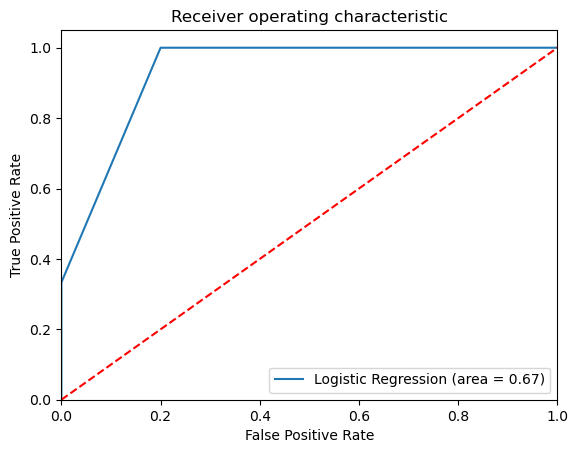

In [34]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt 
logit_roc_auc = roc_auc_score(y_test, logreg.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, logreg.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

[Reference]:(https://github.com/susanli2016/Machine-Learning-with-Python/blob/master/Logistic%20Regression%20balanced.ipynb)

https://github.com/susanli2016/Machine-Learning-with-Python/blob/master/Logistic%20Regression%20balanced.ipynb